In [1]:
pip install transformers torch librosa soundfile matplotlib

Этап 1.Whisper hands-on: от аудио до транскрипции

Цель этапа — пройти весь путь модели руками, от звука до текста, и увидеть глазами, что
происходит на каждом шаге, а не только вызвать model.generate() и получить готовый
ответ. Дальше в проекте придётся встраивать свой слой в декодер — без понимания того,
что творится внутри энкодера, это будет гадание вслепую.

Шаг 1. Скачать модель через AutoModel



In [50]:
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq
import torch

model_id = "openai/whisper-tiny"
processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForSpeechSeq2Seq.from_pretrained(model_id)
model.eval()


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

WhisperForConditionalGeneration(
  (model): WhisperModel(
    (encoder): WhisperEncoder(
      (conv1): Conv1d(80, 384, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv2): Conv1d(384, 384, kernel_size=(3,), stride=(2,), padding=(1,))
      (embed_positions): Embedding(1500, 384)
      (layers): ModuleList(
        (0-3): 4 x WhisperEncoderLayer(
          (self_attn): WhisperAttention(
            (k_proj): Linear(in_features=384, out_features=384, bias=False)
            (v_proj): Linear(in_features=384, out_features=384, bias=True)
            (q_proj): Linear(in_features=384, out_features=384, bias=True)
            (out_proj): Linear(in_features=384, out_features=384, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=384, out_features=1536, bias=True)
          (fc2): Linear(in_features=1536, out_features=384, bias=True)
          (fin

In [3]:
print(sum(p.numel() for p in model.parameters()))

37760640


Шаг 2. Подготовить своё аудио


На аудио спокойным голосом говорится: "Запись тестового сообщения с частотой 16 килогерц для виспера"

In [2]:
import librosa
audio, sr = librosa.load("/content/output.wav", sr=16000, mono=True)


Whisper обучался на аудио 16 кгц, моно режиме.
Запись с частотой дискретизации 16 кгц может содержать частоты только до 8 кгц. Модель обучалась на данных аудиозаписей человека, и она должна была обучиться понимать человеческую речь, все основные признаки (тональность, фонемы и т д) которой как раз находятся в диапазоне до 8 кгц. Если взять другую частоту, то ее мел спектрограмма будет некорректной и речь станет искаженной, она будет отличаться от обучающих данных.
WAV формат подходит как удобный, несжатый формат с удобным представлением амплитуд.
Стерео режим не нужен, потому что это лишняя информация о пространстве, отражении в помещении, да и он меняет формат, который ожидается на входе модели, которая ожидает один аудиосигнал. Для обучения нужен именно голос, для которого достаточно моно режима.

Шаг 3. Построение и реализация своей мел-спектрограммы

Модель не смотрит на сырую волну — на вход идёт мел-спектрограмма: звук разбит на
короткие окна по времени, в каждом окне посчитан спектр, частоты пересчитаны в мелшкалу, которая ближе к тому, как высоту звука различает человеческое ухо (на низких
частотах чувствительность выше, на высоких — ниже, шкала это учитывает и заодно
сжимает размерность).


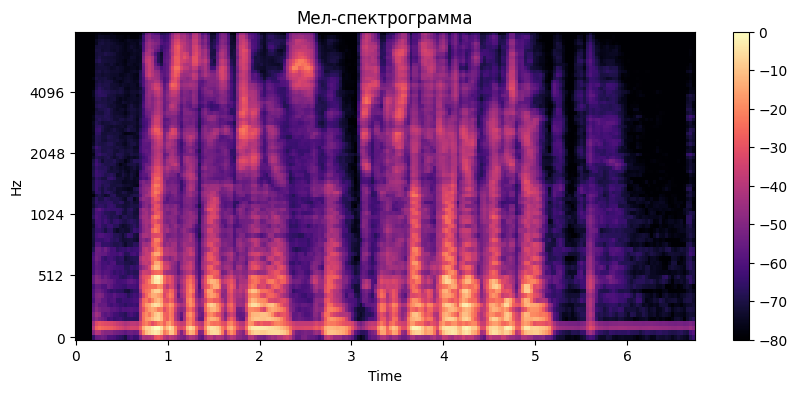

In [3]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=80)
mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar()
plt.title("Мел-спектрограмма")
plt.show()


In [40]:
inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
print(inputs["input_features"].shape)


torch.Size([1, 80, 3000])


Картинки должны быть похожи по смыслу, но из за деталей нормализации в процессоре, могут быть различия.

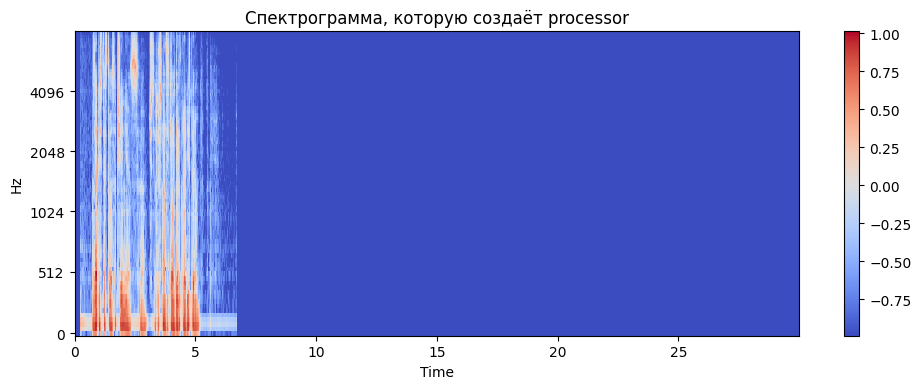

In [41]:
whisper_mel = (
    inputs["input_features"][0]
    .detach()
    .cpu()
    .numpy()
)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    whisper_mel,
    sr=16000,
    hop_length=160,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()
plt.title("Спектрограмма, которую создаёт processor")
plt.tight_layout()
plt.show()

Так выглядит мел-спектрограмма, полученная шагом преобразования в мел-спектрограмму у Whisper, без преобразований. Здесь много пустоты, потому что Whisper обрабатывает аудио блоками по 30 секунд, и соответственно дополнил мою запись пустотой. Часть моего голоса совпадает по смыслу с тем, что строила librosa, хотя немного отличается из-за нормализации.

Шаг 4. Свои первые два свёрточных слоя энкодера

Ствол энкодера Whisper — не трансформерные блоки, а два слоя Conv1d перед ними.
Свёртка одномерная, а не двумерная: ось одна — время, каналы — 80 мел-фильтров.
Первый слой не меняет длину по времени, второй идёт с шагом 2 и укорачивает
последовательность вдвое — так энкодер снижает частоту дискретизации по времени до
того, как передать данные в трансформер, иначе последовательность была бы слишком
длинной для внимания.


In [15]:
import torch.nn as nn
import torch.nn.functional as F

class MiniEncoderStem(nn.Module):
  def __init__(self, n_mels=80, d_model=384):
    super().__init__()
    self.conv1 = nn.Conv1d(n_mels, d_model, kernel_size=3, padding=1)
    self.conv2 = nn.Conv1d(d_model, d_model, kernel_size=3, stride=2, padding=1)

  def forward(self, x):
    print("Форма входа:", x.shape)

    x = self.conv1(x)
    print("После conv1:", x.shape)

    x = F.gelu(x)
    print("После первого GELU:", x.shape)

    x = self.conv2(x)
    print("После conv2:", x.shape)

    x = F.gelu(x)
    print("После второго GELU:", x.shape)

    return x


In [16]:
stem = MiniEncoderStem()

x = inputs["input_features"]

with torch.no_grad():
  output = stem(x)

Форма входа: torch.Size([1, 80, 3000])
После conv1: torch.Size([1, 384, 3000])
После первого GELU: torch.Size([1, 384, 3000])
После conv2: torch.Size([1, 384, 1500])
После второго GELU: torch.Size([1, 384, 1500])


Сейчас у stem были рандомные веса, нужно взять их у Whisper, сравнить и понять, что выход одинаков с точностью до погрешности.

In [29]:
stem = MiniEncoderStem(
    d_model = model.config.d_model
)

stem.conv1.load_state_dict(model.model.encoder.conv1.state_dict())
stem.conv2.load_state_dict(model.model.encoder.conv2.state_dict())

with torch.no_grad():
  output = stem(x)
  conv_after_conv1 = F.gelu(stem.conv1(x))
  conv_after_conv2 = F.gelu(stem.conv2(conv_after_conv1))


Форма входа: torch.Size([1, 80, 3000])
После conv1: torch.Size([1, 384, 3000])
После первого GELU: torch.Size([1, 384, 3000])
После conv2: torch.Size([1, 384, 1500])
После второго GELU: torch.Size([1, 384, 1500])


In [30]:
with torch.no_grad():
  whisper_after_conv1 = F.gelu(model.model.encoder.conv1(x))
  whisper_after_conv2 = F.gelu(model.model.encoder.conv2(whisper_after_conv1))

print("Разница между 1 слоями CNN в Whisper и обычной conv: ", whisper_after_conv1 - conv_after_conv1)
print("Разница между 2 слоями CNN в Whisper и обычной conv: ", whisper_after_conv2 - conv_after_conv2)


print("Max1: ", (whisper_after_conv1 - conv_after_conv1).abs().max().item())
print("Max2: ", (whisper_after_conv2 - conv_after_conv2).abs().max().item())

Разница между 1 слоями CNN в Whisper и обычной conv:  tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])
Разница между 2 слоями CNN в Whisper и обычной conv:  tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])
Max1:  0.0
Max2:  0.0


Шаг 5. Полный проход через модель — транскрипция

In [44]:
with torch.no_grad():
  predicted_ids = model.generate(
      **inputs,
      language="ru",
      task="transcribe"
  )

text = processor.batch_decode(predicted_ids, skip_special_tokens=True)
print(text)

[' Записте стого сообщения с 14 килогрт ловистпером.']


Результат слабо совпадает с тем, что на аудио, точно удалось транскрибировать только слово "сообщения". Я думаю, проблема в маленьком количестве параметров модели tiny, маленькой длине записи (маленькое внимание) и негромком голосе.